# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [7]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [3]:
import os
import pandas as pd
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


In [9]:
import pandas as pd

df = pd.read_csv(path+"/ENB2012_data.csv")

print(df.head())
print(df.shape)

     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28
(768, 10)


In [11]:
X = df[['X1','X2','X3','X4','X5','X6','X7','X8']]
Y1 = df['Y1']   # Heating Load
Y2 = df['Y2']   # Cooling Load

In [12]:
corr = Y1.corr(Y2)
print("Correlation =", corr)

Correlation = 0.9758618134328573


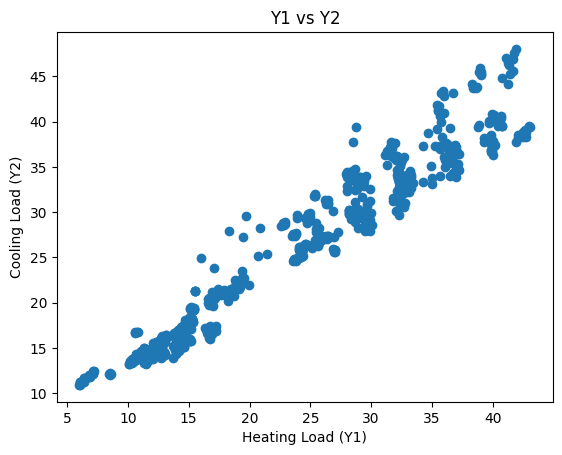

In [13]:
import matplotlib.pyplot as plt

plt.scatter(Y1, Y2)
plt.xlabel("Heating Load (Y1)")
plt.ylabel("Cooling Load (Y2)")
plt.title("Y1 vs Y2")
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y1_train, y1_test = train_test_split(
    X_scaled, Y1, test_size=0.2, random_state=42)

kernel = RBF() + WhiteKernel()

gp_y1 = GaussianProcessRegressor(kernel=kernel)
gp_y1.fit(X_train, y1_train)

y1_pred = gp_y1.predict(X_test)

print("Heating Load")
print("R² =", r2_score(y1_test, y1_pred))
print("RMSE =", np.sqrt(mean_squared_error(y1_test, y1_pred)))

Heating Load
R² = -0.16928279720377337
RMSE = 11.039753532345022


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [15]:
X_train, X_test, y2_train, y2_test = train_test_split(
    X_scaled, Y2, test_size=0.2, random_state=42)

gp_y2 = GaussianProcessRegressor(kernel=kernel)
gp_y2.fit(X_train, y2_train)

y2_pred = gp_y2.predict(X_test)

print("Cooling Load")
print("R² =", r2_score(y2_test, y2_pred))
print("RMSE =", np.sqrt(mean_squared_error(y2_test, y2_pred)))

Cooling Load
R² = -0.20481354718662148
RMSE = 10.565732071662712


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [17]:
Y_combined = (Y1 + Y2) / 2

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y_combined, test_size=0.2, random_state=42)

gp_combined = GaussianProcessRegressor(kernel=kernel)
gp_combined.fit(X_train, y_train)

y_pred = gp_combined.predict(X_test)

print("Combined Output")
print("R² =", r2_score(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))

Combined Output
R² = -0.18585285062138102
RMSE = 10.729871474576518


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [4]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [6]:
import os
import pandas as pd
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")

Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv


In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset - Using the specific path for the green building dataset
green_building_path = "/kaggle/input/green-building-multi-source-environment-dataset"
df = pd.read_csv(green_building_path + "/green_building_dataset.csv")

print("="*50)
print("QUESTION 1: MULTIPLE LINEAR REGRESSION")
print("="*50)

# Define features and target for Q1
X1_cols = ['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'outdoor_temperature', 'solar_radiation', 'occupancy']
y1_col = 'predicted_energy_demand'

X1 = df[X1_cols]
y1 = df[y1_col]

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X1, y1)

# Predict and Evaluate
y1_pred = lr_model.predict(X1)
r2_q1 = r2_score(y1, y1_pred)
mse_q1 = mean_squared_error(y1, y1_pred)

print(f"Intercept: {lr_model.intercept_:.4f}")
print("\nCoefficients:")
for col, coef in zip(X1_cols, lr_model.coef_):
    print(f"  {col}: {coef:.4f}")

print(f"\nModel Performance Metrics:")
print(f"  R-squared (R2): {r2_q1:.4f}")
print(f"  Mean Squared Error (MSE): {mse_q1:.4f}")


print("\n" + "="*50)
print("QUESTION 2: DECISION TREE REGRESSOR")
print("="*50)

# Define target and drop energy variables as requested
y2_col = 'predicted_comfort_index'
X2_cols = [col for col in df.columns if col not in ['predicted_comfort_index', 'predicted_energy_demand']]

X2 = df[X2_cols]
y2 = df[y2_col]

# Perform 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Train Decision Tree Regressor (max_depth=5)
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predict and Evaluate on test set
y2_pred = dt_model.predict(X_test)
r2_q2 = r2_score(y_test, y2_pred)
mse_q2 = mean_squared_error(y_test, y2_pred)

print(f"Test Set Performance Metrics:")
print(f"  R-squared (R2): {r2_q2:.4f}")
print(f"  Mean Squared Error (MSE): {mse_q2:.4f}")

# Extract and sort feature importances
importances = dt_model.feature_importances_
feature_rankings = sorted(zip(X2_cols, importances), key=lambda x: x[1], reverse=True)

print("\nTop 3 Most Important Features:")
for i in range(3):
    name, importance_val = feature_rankings[i]
    print(f"  {i+1}. {name}: {importance_val * 100:.2f}%")

QUESTION 1: MULTIPLE LINEAR REGRESSION
Intercept: 33.6161

Coefficients:
  indoor_temperature: -0.0208
  indoor_humidity: 0.0064
  co2_concentration: -0.0008
  outdoor_temperature: 0.0055
  solar_radiation: 0.0002
  occupancy: 0.0382

Model Performance Metrics:
  R-squared (R2): 0.0049
  Mean Squared Error (MSE): 90.9132

QUESTION 2: DECISION TREE REGRESSOR
Test Set Performance Metrics:
  R-squared (R2): 0.0912
  Mean Squared Error (MSE): 0.0003

Top 3 Most Important Features:
  1. indoor_noise: 37.11%
  2. indoor_temperature: 23.52%
  3. indoor_lighting: 22.49%
